# Building the graph dataset

In [1]:
import netCDF4 as nc
import xarray as xr
import numpy as np
import torch
from torch_geometric.data import Data

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.checkpoint import checkpoint
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch.utils.data import SubsetRandomSampler
from torch_geometric.nn import GCNConv, TransformerConv, TopKPooling, radius_graph
from dask.diagnostics import ProgressBar
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import StepLR
import gc
import random

from model import STGAETransformerPoolingMultiGCN
from dataset import chunk_to_graph, TemperatureGraphDataset

In [2]:
import os
dataset_base_directory = os.curdir+os.sep+"dataset"
dataset_files = dataset_base_directory+os.sep+'*.nc4'

In [3]:
lat_min, lat_max = 30, 60
lon_min, lon_max = 0, 30
temp_window = 25

In [4]:
ds = xr.open_mfdataset(dataset_files, cache=False)
ds = ds.sel(
    lat=slice(lat_min, lat_max), 
    lon=slice(lon_min, lon_max) 
)
ds = ds.chunk({'time': temp_window})
ds['Tb'] = ds['Tb'].astype('float16')
ds

<xarray.Dataset> Size: 8GB
Dimensions:  (time: 5708, lat: 825, lon: 825)
Coordinates:
  * lon      (lon) float32 3kB 0.01819 0.05457 0.09094 ... 29.92 29.96 29.99
  * lat      (lat) float32 3kB 30.0 30.04 30.07 30.11 ... 59.91 59.95 59.98
  * time     (time) datetime64[ns] 46kB 2020-01-01 ... 2020-04-28T21:30:00.00...
Data variables:
    Tb       (time, lat, lon) float16 8GB dask.array<chunksize=(25, 825, 825), meta=np.ndarray>
Attributes:
    BeginDate:       2020-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2020-01-01
    EndTime:         00:59:59.999Z
    FileHeader:      StartGranuleDateTime=2020-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    merg_2020010100_4km-pixel
    title:           NCEP/CPC 4km Global (60N - 60S) IR Dataset
    ProductionTime:  2020-01-03T00:19:23.203Z

In [5]:
mean_temp = ds['Tb'].mean().compute()
std_temp = ds['Tb'].std().compute()

ds['Tb'] = (ds['Tb'] - mean_temp) / std_temp

In [6]:
print(f'Mean temp: {mean_temp}, Std temp: {std_temp}')

Mean temp: 272.51712, Std temp: 15.239919


In [7]:
Tb = ds.variables['Tb'][:]     
lat = ds.variables['lat'][:]      
lon = ds.variables['lon'][:]     
time = ds.variables['time'][:]    

print("Shapes: Tb:", Tb.shape, "lat:", lat.shape, "lon:", lon.shape, "time:", time.shape)

Shapes: Tb: (5708, 825, 825) lat: (825,) lon: (825,) time: (5708,)


### Null values handling
since null values distribution represents useful information, we decided to impute them and to mask them and use this data during training

## Graph preparation
Dataset subsetting

In [8]:
batch_size = 2
dataset = TemperatureGraphDataset(ds, 'Tb', temp_window)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [9]:
def compute_loss(x_recon, target, loss_type="mse", temp_weight=1.0, mask_weight=0.2):
    T = x_recon.size(1) // 2
    recon_temp = x_recon[:, :T]
    target_temp = target[:, :T]
    recon_mask = x_recon[:, T:]
    target_mask = target[:, T:]
    if loss_type == "mse":
        loss_temp = F.mse_loss(recon_temp, target_temp, reduction='mean')
        loss_mask = F.mse_loss(recon_mask, target_mask, reduction='mean')
    elif loss_type == "mae":
        loss_temp = F.l1_loss(recon_temp, target_temp, reduction='mean')
        loss_mask = F.l1_loss(recon_mask, target_mask, reduction='mean')
    elif loss_type == "smooth_l1":
        loss_temp = F.smooth_l1_loss(recon_temp, target_temp, reduction='mean')
        loss_mask = F.smooth_l1_loss(recon_mask, target_mask, reduction='mean')
    else:
        raise ValueError("Unsupported loss type: " + loss_type)

    return temp_weight * loss_temp + mask_weight * loss_mask

In [10]:
loss_type = "mse"

In [11]:
hidden_channels = 64
latent_dim = 16
num_epochs = 8
initial_lr = 0.001   
lr_decay_epochs = num_epochs-2 
lr_gamma = 0.5       
checkpoint_dir = "./anomaly_detector"
accumulation_steps = 2

subsample_fraction = 0.4
num_total_chunks = len(dataset)
num_sampled_chunks = int(subsample_fraction * num_total_chunks)
os.makedirs(checkpoint_dir, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scaler = GradScaler('cuda')
model = STGAETransformerPoolingMultiGCN(temp_window*2, hidden_channels, latent_dim).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)

scheduler = StepLR(optimizer, step_size=lr_decay_epochs, gamma=lr_gamma)


Efficiency considerations: 
1. gradient accumulation (accumulate gradients over multiple steps before performing a parameter update, which can reduce the overall memory consumption)


In [12]:
def train_one_epoch(loader, model, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = len(loader)

    pbar = tqdm(loader, desc="Training Epoch", unit="batch")
    optimizer.zero_grad()
    for step, data in enumerate(pbar):
        data = data.to(device)
        with autocast('cuda'):
            x_recon, _, perm = model(data)
            loss = compute_loss(x_recon, data.x[perm], loss_type=loss_type)
        
        scaler.scale(loss).backward()


        if ((step + 1) % accumulation_steps == 0) or (step+1 == len(loader)):
            # optimizer.step()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        del data, x_recon, loss
        torch.cuda.empty_cache()
    avg_loss = total_loss / num_batches
    return avg_loss

def evaluate(loader, model, device, max_batches=10):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    with torch.no_grad():
        for i, data in enumerate(tqdm(loader, desc="Evaluation", unit="batch", total=max_batches)):
            if i >= max_batches:
                break
            data = data.to(device)
            with autocast('cuda'):
                x_recon, _, perm = model(data)
                loss = compute_loss(x_recon, data.x[perm], loss_type=loss_type)
            total_loss += loss.item()
            num_batches += 1
            del data, x_recon, loss
            torch.cuda.empty_cache()
    if num_batches == 0:
        return float('nan')
    return total_loss / num_batches



In [13]:
train_losses = []
val_losses = []

In [14]:

for epoch in range(1, num_epochs+1):
    print(f"################ EPOCH {epoch} #################")
    if epoch <= num_epochs-1:
        sampled_indices = random.sample(range(num_total_chunks), num_sampled_chunks)
        sampler = SubsetRandomSampler(sampled_indices)    
        loader_sample = DataLoader(dataset, batch_size=batch_size, sampler=sampler)
        avg_train_loss = train_one_epoch(loader_sample, model, optimizer, device)
        avg_val_loss = evaluate(loader_sample, model, device)
    else:
        avg_train_loss = train_one_epoch(loader, model, optimizer, device)
        avg_val_loss = evaluate(loader, model, device)
    print(f"Epoch {epoch:03d}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    scheduler.step() 
    checkpoint_path = os.path.join(checkpoint_dir, f"stgae_epoch_{epoch}.pth")
    torch.save(model.state_dict(), checkpoint_path)
    print(f"Saved checkpoint: {checkpoint_path}")
    model.to('cpu')
    gc.collect()
    torch.cuda.empty_cache()
    model.to('cuda')

################ EPOCH 1 #################


Evaluation: 100%|██████████| 10/10 [01:11<00:00,  7.17s/batch]


Epoch 001: Train Loss = 1.8000, Val Loss = 1.1182
Saved checkpoint: ./anomaly_detector/stgae_epoch_1.pth
################ EPOCH 2 #################


Evaluation: 100%|██████████| 10/10 [01:10<00:00,  7.03s/batch]


Epoch 002: Train Loss = 0.8024, Val Loss = 0.5940
Saved checkpoint: ./anomaly_detector/stgae_epoch_2.pth
################ EPOCH 3 #################


...

Epoch 006: Train Loss = 0.4158, Val Loss = 0.3413
Saved checkpoint: ./anomaly_detector/stgae_epoch_6.pth
################ EPOCH 7 #################


Evaluation: 100%|██████████| 10/10 [01:10<00:00,  7.01s/batch]


Epoch 007: Train Loss = 0.2931, Val Loss = 0.2936
Saved checkpoint: ./anomaly_detector/stgae_epoch_7.pth
################ EPOCH 8 #################


Evaluation: 100%|██████████| 10/10 [01:12<00:00,  7.28s/batch]


Epoch 008: Train Loss = 0.2595, Val Loss = 0.2728
Saved checkpoint: ./anomaly_detector/stgae_epoch_8.pth


In [15]:
# ==============================
# 6. Example Evaluation on a Sample Graph
# ==============================
def evaluate_sample(data, model, device):
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        with autocast('cuda'):
            x_recon, z, perm = model(data)
    error = compute_loss(x_recon, data.x[perm], loss_type=loss_type)
    del data, x_recon
    torch.cuda.empty_cache()
    return error, z

sample = dataset.get(0)
error, latent = evaluate_sample(sample, model, device)
print("Average reconstruction error per node for sample:", error.mean().item())

Average reconstruction error per node for sample: 0.30461058020591736


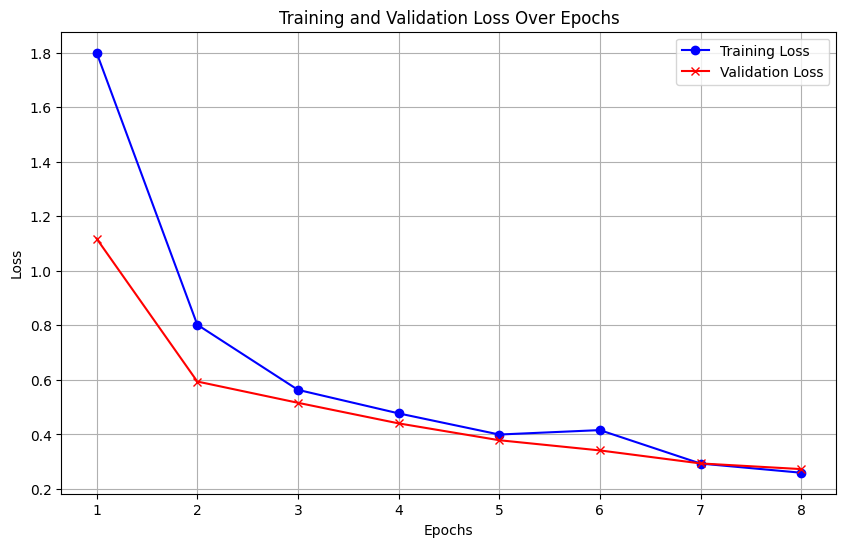

In [16]:
import matplotlib.pyplot as plt

# Assuming 'loss' and 'val' are your data arrays
# Ensure that both arrays have the same length
if len(val_losses) != len(train_losses):
    raise ValueError("The 'loss' and 'val' arrays must have the same length.")

# Create an array for the x-axis, e.g., epochs or iterations
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', color='red', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()